# 01 — Veri İnceleme

Ham Hepsiburada yorum veri setinin yapısı, veri kalitesi ve sınıf dağılımı incelenir.


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

proje_koku = Path.cwd()
if proje_koku.name == "notebooks":
    proje_koku = proje_koku.parent

raw_data_path = proje_koku / "data" / "raw" / "hepsiburada_balanced_300k.csv"
df = pd.read_csv(raw_data_path)
df.head()


,combined_text,label
0,İki Yıldız. iyi,0
1,Bir Yıldız. kargo sorunsuz geldi ama tam 1 haf...,0
2,Kokusu dışında iş görür. Çok fazla koku yapıyo...,0
3,kötü. saat içinden çıkıyor beklediğim gibi kal...,0
4,Çok kötü.... Almayın çok kötü boşa para verirs...,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   combined_text  300000 non-null  str  
 1   label          300000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 4.6 MB


In [4]:
print(df.shape)

(300000, 2)


In [5]:
print(df["label"].value_counts())

label
0    100000
1    100000
2    100000
Name: count, dtype: int64


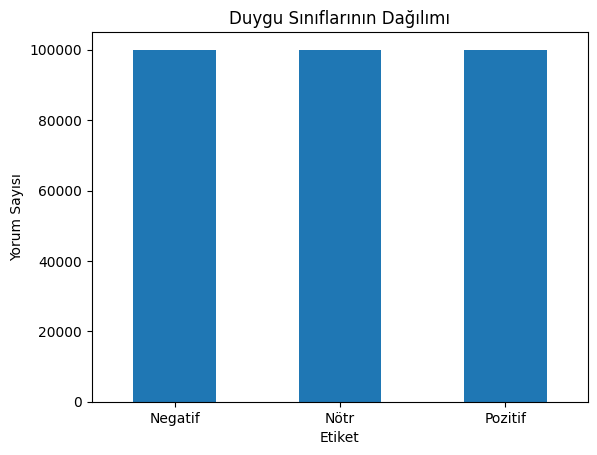

In [6]:
df["label"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Duygu Sınıflarının Dağılımı")
plt.xlabel("Etiket")
plt.ylabel("Yorum Sayısı")
plt.xticks(
    [0, 1, 2],
    ["Negatif", "Nötr", "Pozitif"],
    rotation=0
)
plt.show()

In [7]:
print(df.isnull().sum())


combined_text    0
label            0
dtype: int64


In [8]:
print(df["combined_text"].duplicated().sum())

53018


In [9]:
celiskili_metinler = (
    df.groupby("combined_text")["label"]
      .nunique()
)

celiskili_metinler = celiskili_metinler[celiskili_metinler > 1]

print("Farklı etiketli aynı metin sayısı:", len(celiskili_metinler))

Farklı etiketli aynı metin sayısı: 33


In [8]:
df[df["combined_text"].isin(celiskili_metinler.index)] \
    .sort_values("combined_text") \
    .head(30)

,combined_text,label
194260,Anakart Yanıyor. Kesinlikle almayın Bir süre s...,1
82663,Anakart Yanıyor. Kesinlikle almayın Bir süre s...,0
243341,Başarılı. Başarılı,2
190099,Başarılı. Başarılı,1
186680,Başarılı. Başarılı,1
107076,Başarılı. Başarılı,1
220910,Başarılı. Başarılı,2
126923,Başarılı. Başarılı,1
289170,F/P. indirimde bulursanız kaçırmayın ben indir...,2
124336,F/P. indirimde bulursanız kaçırmayın ben indir...,1
